`WUR Machine Learning Course - Assignment 3 (classification) - Version 2025`

# Multispectral Land Cover Classification

Welcome to the second project of the MGI track of the course! In this exercise we will be performing a typical machine learning task for remote sensing: classifying land cover from Sentinel-2 images.

This notebook provides you with a starting baseline model. Your task will be to improve this model during a live Kaggle competition https://www.kaggle.com/competitions/wur-fte-35306-mgi-2024-2025. There is no code to be filled. You need to improve upon the (quite bad) baseline model provided in this notebook!

Please join the competition as a team with this link: https://www.kaggle.com/t/a1dfe6ac4f144f70b77eb070808437cc

**Note, this exercise is about creativity. You are allowed to do everything that improves the final score**. In the submitted report, we will evaluate your effort, approach and creativity. **We will not evaluate your competition final score**. Also, **it is not a competition between teams**: we work together to get the best possible land cover map for Wageningen. Don't be secret about your discoveries and share information freely. If you run out of ideas, ask google/ChatGPT, other teams, or the teaching assistants (please in this order)

The evaluation metric is the class-average i.e., "macro" jaccard index, which is also known as intersection over union. It ensures that your final model predicts all land cover classes well.

## KATSAPLIADES ($\leftarrow$ please replace)

Members:
* Gkoufas Pantelis Georgios ($\leftarrow$ please replace)
* Karakostas Dimitrios ($\leftarrow$ please replace)

## Project Report

**Please submit 2 files: a PDF report of your progress to Brightspace and attach this notebook as code in .ipynb format**

The report should have at most 4 pages excluding references and the appendix. Please add an experiment log to the appendix where you record what models you tried.

### Structure and Evaluation

1. Introduction (0.5 pages): Description of problem (10% weight)
2. Methodology & Questions  (1 pages): Description and motivation of final choice of your methodology. (no explanation of the ML
methods, but why and how used) (20% weight)
3. Results (1 page): Presentation/evaluation of main results - quality of figures and tables (standard deviations) (20% weight)
4. Ethics (1/3 pages): Ethical, Legal, and Social Aspects (ELSA) reflection (15% weight)
5. Discussion (1/3 pages): Discussion of your final model (limitations and advantages) (15% weight)
6. Conclusion and Outlook (1/3 pages): what could be improved further (10% weight)
8. Appendix (not counting to page limit): Brief AI Statement Experiment Log what you tried.

### Reflection (not part of the report)

These questions are meant to give some ideas towards directions to explore that may improve the final score. Note, you can/should use Google (and ChatGPT) to give you some ideas and strategies.

**Question 1:** What performance gain did you see when improving the data, e.g., through feature engineering versus improving the classifier, e.g., though better hyperparameter tuning, or another classifier? Please reply briefly.
**Answer 1:**

**Question 2:** How can you automate or streamline the hyperparameter tuning process? Did you implement a cross-validation strategy? Which effect did it have on your output?
**Answer 2:**

**Question 3:** How can you improve the data through feature engineering? What spectral features can you implement? Can you think of (or google) textural features/patterns that may help?
**Answer 3:**

**Question 4:** Why is the Jaccard score (i.e., Intersection over Union) in Renkum lower than in Arnhem?
**Answer 4:**

### Experiment Log

Please add a similar table in the appendix of the report. But write only about the best final model in your main report.

| Version/Submission ID | submission macro Jaccard | Note                  |
|-----------------------|--------------------------|-----------------------|
| v1                    | .15995                   | baseline DT, RGB data |
| v1.1                  | ...                      | ...                   |
| v1.2                  | ...                      | ...                   |
| ...                   | ...                      | ...                   |

If necessary, you can provide here additional information to the individual submissions:
e.g.,
* v1 just submitted the baseline code
* v1.2 tried variant X
* v1.2 tried something else, but didnt work
* ...


# Land Cover Data in this Exercise

We provide you with a Sentinel-2 images from May 18th, 2017 with 12 spectral bands and a land cover image from the [S2GLC land cover map](https://s2glc.cbk.waw.pl/).

Your task will be to train a classifier on data from Arnhem and Renkum to predict land cover of Wageningen as accurately as possible

In [ ]:
#install rasterio and tensorflow
!pip install tensorflow
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 63.0 MB/s eta 0:00:00


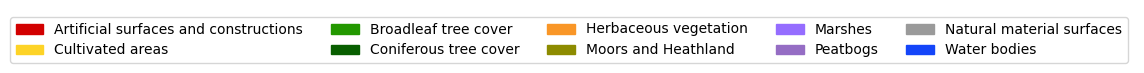

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import pandas as pd
import zipfile
import os
import sklearn
from sklearn.model_selection import train_test_split

bands = [
    "B1",  # idx 0: Coastal aerosol
    "B2",  # idx 1: Blue
    "B3",  # idx 2: Green
    "B4",  # idx 3: Red
    "B5",  # idx 4: Red edge 1
    "B6",  # idx 5: Red edge 2
    "B7",  # idx 6: Red edge 3
    "B8",  # idx 7: NIR (Near-Infrared)
    "B8A", # idx 8: Red edge 4
    "B10", # idx 9: Haze Clouds
    "B11", # idx 10: SWIR 1
    "B12", # idx 11: SWIR 2
]

color_map_entries = {
    58: {"id":0, "color": "#D20000", "name": "Artificial surfaces and constructions"},
    68: {"id":1, "color": "#FDD327", "name": "Cultivated areas"},
    76: {"id":2, "color": "#239800", "name": "Broadleaf tree cover"},
    77: {"id":3, "color": "#085E00", "name": "Coniferous tree cover"},
    95: {"id":4, "color": "#F99627", "name": "Herbaceous vegetation"},
    96: {"id":5, "color": "#8D8B00", "name": "Moors and Heathland"},
    98: {"id":6, "color": "#956DFF", "name": "Marshes"},
    99: {"id":7, "color": "#956DC4", "name": "Peatbogs"},
    113:{"id":8, "color": "#9A9A9A", "name": "Natural material surfaces"},
    151:{"id":9, "color": "#1445F9", "name": "Water bodies"},
}

hex_colors = [v["color"] for v in color_map_entries.values()]
s2glc_cmap = ListedColormap(hex_colors)

def plot_legend():
    # plot the colors with names of the color map
    hex_colors = [v["color"] for v in color_map_entries.values()]
    color_names = [v["name"] for v in color_map_entries.values()]
    legend_elements = [Patch(color=color, label=name) for color, name in zip(hex_colors, color_names)]
    plt.figure(figsize=(.1,.1))
    plt.legend(handles=legend_elements, ncols=5, loc='upper right')
    plt.axis('off')
plot_legend()



## Data Overview

Here, we provide an overview over the images and land cover ground truth. Your task is to produce a land cover map for wageningen, which as as accurate as possible measured by the macro Intersection over Union score.

* Training: Arnhem
* Validation: Renkum
* Testing: Wageningen

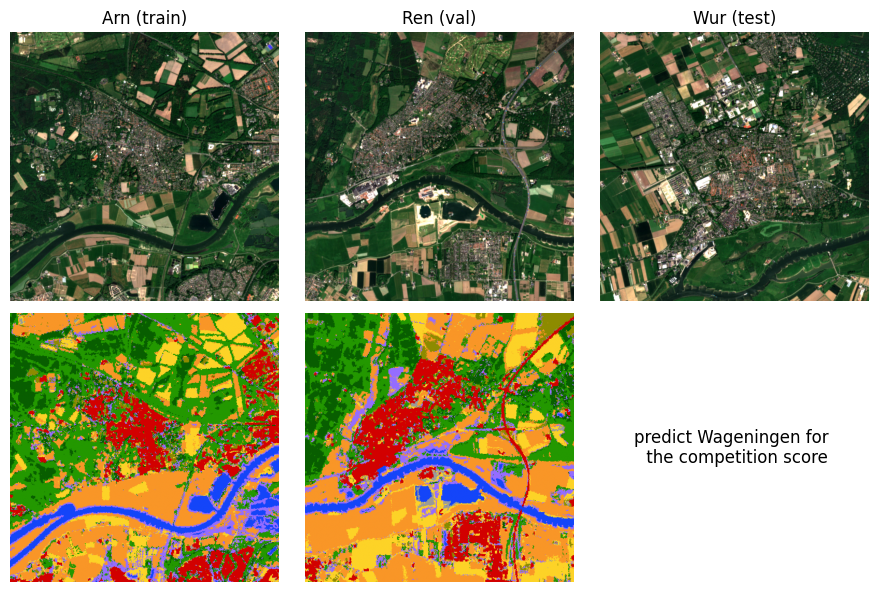

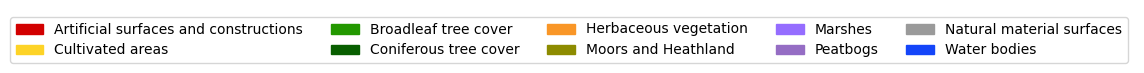

In [ ]:

with rasterio.open("s2_arn.tif") as src:
    s2_arn = src.read()[np.array([bands.index("B4"), bands.index("B3"), bands.index("B2")])]

with rasterio.open("lc_arn.tif") as src:
    lc_arn = src.read(1)

with rasterio.open("s2_ren.tif") as src:
    s2_ren = src.read()[np.array([bands.index("B4"), bands.index("B3"), bands.index("B2")])]

with rasterio.open("lc_ren.tif") as src:
    lc_ren = src.read(1)

with rasterio.open("s2_wur.tif") as src:
    s2_wur = src.read()[np.array([bands.index("B4"), bands.index("B3"), bands.index("B2")])]



fig, axs = plt.subplots(2,3, figsize=(9,6))
axs = axs.reshape(-1)

# first row
axs[0].imshow(np.clip(s2_arn.transpose(1,2,0) / 2000,0,1))
axs[1].imshow(np.clip(s2_ren.transpose(1,2,0) / 2000,0,1))
axs[2].imshow(np.clip(s2_wur.transpose(1,2,0) / 2000,0,1))

# second row
axs[3].imshow(lc_arn, cmap=s2glc_cmap)
axs[4].imshow(lc_ren, cmap=s2glc_cmap)
axs[5].text(0.5,0.5, "predict Wageningen for \n the competition score", ha="center", va="center", fontsize=12)

# titles
axs[0].set_title("Arn (train)")
axs[1].set_title("Ren (val)")
axs[2].set_title("Wur (test)")

# remove boxes around plots
for ax in axs:
    ax.axis("off")

# add land cover legend and make plots a bit tighter
plt.tight_layout()
plot_legend()

## Your Model Implementation

We will provide you the most simple baseline you can imagine: A classifier that predicts zeros. Your task will be to improve upon it.

Then, we provide you with code write a submission file. Upload this file to the Kaggle server get appear in the leaderboard.

Loading the images with all the bands(12)

In [ ]:
#load the data with all the bands
with rasterio.open("s2_arn.tif") as src:
    s2_arn = s2_arn = src.read()

with rasterio.open("lc_arn.tif") as src:
    lc_arn = src.read(1)

with rasterio.open("s2_ren.tif") as src:
    s2_ren = src.read()

with rasterio.open("lc_ren.tif") as src:
    lc_ren = src.read(1)

with rasterio.open("s2_wur.tif") as src:
    s2_wur = src.read()

Calculating the NDVI and NDWI with the bands of the sattelite image

In [ ]:
# Compute NDVI and NDWI for Arnhem (training set)
ndvi_arn = (s2_arn[7] - s2_arn[3]) / (s2_arn[7] + s2_arn[3])
ndwi_arn = (s2_arn[2] - s2_arn[10]) / (s2_arn[2] + s2_arn[10])

# Compute NDVI and NDWI for Renkum (validation set)
ndvi_ren = (s2_ren[7] - s2_ren[3]) / (s2_ren[7] + s2_ren[3])
ndwi_ren = (s2_ren[2] - s2_ren[10]) / (s2_ren[2] + s2_ren[10])

# Compute NDVI and NDWI for Wageningen (test set)
ndvi_wur = (s2_wur[7] - s2_wur[3]) / (s2_wur[7] + s2_wur[3])
ndwi_wur = (s2_wur[2] - s2_wur[10]) / (s2_wur[2] + s2_wur[10])

Adding 2 extra features (NDVI and NDWI) gives the model more information about vegetation and water.

In [ ]:
def flatten_image(image, mask=None):
    bands, height, width = image.shape
    flat_image = image.reshape(bands, height * width).T
    if mask is not None:
        flat_mask = mask.flatten()
        valid_pixels = ~np.isnan(flat_mask)
        flat_image = flat_image[valid_pixels]
    return flat_image

# Flatten Sentinel-2 images
X_arn = flatten_image(s2_arn, lc_arn)
X_ren = flatten_image(s2_ren, lc_ren)
X_wur = flatten_image(s2_wur)

# Flatten NDVI and NDWI values
ndvi_arn_flat = ndvi_arn.flatten()
ndwi_arn_flat = ndwi_arn.flatten()
ndvi_ren_flat = ndvi_ren.flatten()
ndwi_ren_flat = ndwi_ren.flatten()
ndvi_wur_flat = ndvi_wur.flatten()
ndwi_wur_flat = ndwi_wur.flatten()

# Flatten the land cover labels (for training)
y_arn = lc_arn.flatten()
y_ren = lc_ren.flatten()

# Convert training and validation data to DataFrame
df_arn = pd.DataFrame(X_arn)
df_arn["ndvi"] = ndvi_arn_flat
df_arn["ndwi"] = ndwi_arn_flat
df_arn["label"] = y_arn

df_ren = pd.DataFrame(X_ren)
df_ren["ndvi"] = ndvi_ren_flat
df_ren["ndwi"] = ndwi_ren_flat
df_ren["label"] = y_ren

# Convert test data (Wageningen) to DataFrame
df_wur = pd.DataFrame(X_wur)
df_wur["ndvi"] = ndvi_wur_flat
df_wur["ndwi"] = ndwi_wur_flat

print(df_arn.head(2))
print(df_ren.head(2))
print(df_wur.head(2))

     0    1    2    3    4     5     6     7     8     9    10   11      ndvi  \
0  206  207  421  136  724  2750  3384  3865  3644  3126  1507  648  0.932017   
1  152  289  556  273  926  2974  3535  4363  3836  3022  1894  891  0.882226   
2  152  338  596  365  926  2974  3535  3832  3836  3022  1894  891  0.826066   
3  152  306  571  313  752  2167  2615  3478  2871  3022  1580  795  0.834872   
4  152  164  305  169  752  2167  2615  2265  2871  3022  1580  795  0.861134   

        ndwi  label  
0  33.428423      2  
1  26.203265      2  
2  25.798394      2  
3  29.998605      3  
4  34.090716      2  
     0    1    2    3    4     5     6     7     8     9    10   11      ndvi  \
0  275  164  203   67  491  2589  2999  2975  3318  3625  1365  568  0.955950   
1  275  222  433  134  755  3322  4280  4210  4059  3625  1461  578  0.938306   
2  275  222  377  120  755  3322  4280  3805  4059  3625  1461  578  0.938854   
3  275  252  378  144  786  3072  4000  3973  4100  3625 

Flattening Sentinel 2 images and converting them in dataframes without adding the ndvi and ndwi indices.

In [ ]:

# Step 1: Create a function to Flatten the Image
def flatten_image(image, mask=None):
  bands, height, width = image.shape
  flat_image = image.reshape(bands, height * width).T
  if mask is not None:
        flat_mask = mask.flatten()
        valid_pixels = ~np.isnan(flat_mask)
        flat_image = flat_image[valid_pixels]

  return flat_image

# Step 2: Use flatten_image function to flatten the Sentinel-2 images
X_arn = flatten_image(s2_arn, lc_arn)
X_ren = flatten_image(s2_ren, lc_ren)
X_wur = flatten_image(s2_wur)

# Step 3: Flatten the land cover labels(for training)
y_arn = lc_arn.flatten()
y_ren = lc_ren.flatten()

# Step 4: Convert training data (Arnhem)and validation data(Renkum) to DataFrame
df_arn = pd.DataFrame(X_arn)
df_arn["label"] = y_arn

df_ren = pd.DataFrame(X_ren)
df_ren["label"] = y_ren

print(df_arn)


          0     1     2     3     4     5     6     7     8     9    10    11  \
0       206   207   421   136   724  2750  3384  3865  3644  3126  1507   648   
1       152   289   556   273   926  2974  3535  4363  3836  3022  1894   891   
2       152   338   596   365   926  2974  3535  3832  3836  3022  1894   891   
3       152   306   571   313   752  2167  2615  3478  2871  3022  1580   795   
4       152   164   305   169   752  2167  2615  2265  2871  3022  1580   795   
...     ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   
249995  886  1351  1694  1946  1909  3089  3403  3517  3749  3260  2888  2124   
249996  886  1108  1506  1690  1909  3089  3403  3660  3749  3260  2888  2124   
249997  886   698  1006   870  1362  3193  3720  3724  3860  3260  2431  1496   
249998  886   421   726   461  1362  3193  3720  4032  3860  3260  2431  1496   
249999  477   301   667   337  1195  3100  3623  4124  3795  3599  1947  1040   

        label  
0          

# Training set 50% and Validation set 50%

In [ ]:
# Separate features and labels for training
X_train = df_arn.drop(columns=["label"])
y_train = df_arn["label"]

# Separate features and labels for validation
X_val = df_ren.drop(columns=["label"])
y_val = df_ren["label"]

#Training set 70% and Validation set 30%

In [ ]:

# Merge both datasets into one DataFrame
df_merged = pd.concat([df_arn, df_ren], axis=0).reset_index(drop=True)

# Print shape of the merged DataFrame
print(f"Merged Data Shape: {df_merged.shape}")
print(df_merged.head())

# Split merged data into training and validation sets

# Separate features (X) and labels (y)
X = df_merged.drop(columns=["label"])  # All spectral bands as features
y = df_merged["label"]

# Perform train-validation split (70% training, 30% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Print shape of the new splits
print(f"New Training Set: {X_train.shape}, Labels: {y_train.shape}")
print(f"New Validation Set: {X_val.shape}, Labels: {y_val.shape}")

Merged Data Shape: (500000, 13)
     0    1    2    3    4     5     6     7     8     9    10   11  label
0  206  207  421  136  724  2750  3384  3865  3644  3126  1507  648      2
1  152  289  556  273  926  2974  3535  4363  3836  3022  1894  891      2
2  152  338  596  365  926  2974  3535  3832  3836  3022  1894  891      2
3  152  306  571  313  752  2167  2615  3478  2871  3022  1580  795      3
4  152  164  305  169  752  2167  2615  2265  2871  3022  1580  795      2
New Training Set: (350000, 12), Labels: (350000,)
New Validation Set: (150000, 12), Labels: (150000,)


#CLASS BALANCE

Here we tried to check if there is class imbalance

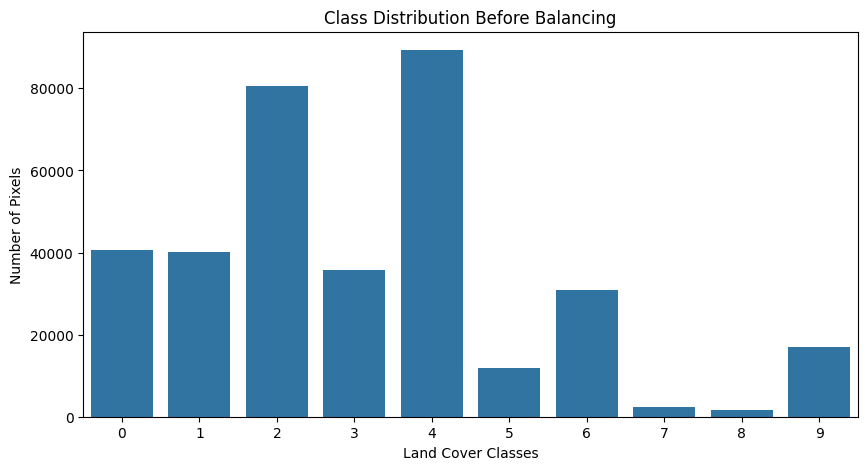

In [ ]:
# check for class imbalance
import seaborn as sns
# Count occurrences of each class in y_train
unique, counts = np.unique(y_train, return_counts=True)

# Plot the class distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=unique, y=counts)
plt.xlabel("Land Cover Classes")
plt.ylabel("Number of Pixels")
plt.title("Class Distribution Before Balancing")
plt.show()

Try to correct the class imblance.

New class distribution: {0: 40576, 1: 40047, 2: 80539, 3: 35827, 4: 89335, 5: 11771, 6: 30860, 7: 10000, 8: 10000, 9: 17048}


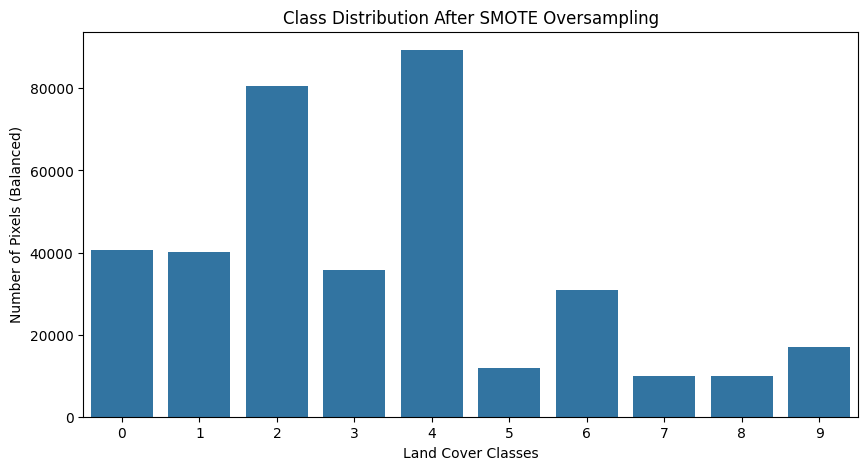

In [ ]:
from imblearn.over_sampling import SMOTE


# Calculate the number of samples for each class
class_counts = np.bincount(y_train)
max_samples = 10000

# Define the sampling strategy:
# We only want to oversample classes with fewer than 60,000 samples to 60,000,
# but leave classes with more than 60,000 samples unchanged.
sampling_strategy = {i: max_samples if count < max_samples else count for i, count in enumerate(class_counts)}

# Apply SMOTE with the updated sampling strategy
sm = SMOTE(sampling_strategy=sampling_strategy, random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

# Check new class distribution
unique_bal, counts_bal = np.unique(y_train_bal, return_counts=True)
print(f"New class distribution: {dict(zip(unique_bal, counts_bal))}")


Plot the classes after the balance apply by using SMOTE

In [ ]:

# Plot the balanced distribution
plt.figure(figsize=(10, 5))
sns.barplot(x=unique_bal, y=counts_bal)
plt.xlabel("Land Cover Classes")
plt.ylabel("Number of Pixels (Balanced)")
plt.title("Class Distribution After SMOTE Oversampling")
plt.show()

#PCA ATTEMPT


If you want to use PCA as a feature engineering method you have to run the code below

Number of Components Selected: 12
Training Set Shape: (350000, 12), Labels: (350000,)
Validation Set Shape: (150000, 12), Labels: (150000,)
Training Set: [[-1.29036920e+00 -2.51817930e+00 -9.65892633e-01 ...  9.74930570e-03
   1.74473679e-01  7.32456600e-02]
 [ 6.05082117e-01  3.18415257e+00 -9.79195697e-02 ...  1.64293860e-02
  -3.99401396e-02 -3.53689991e-02]
 [-7.72311251e-01  3.73307674e+00 -2.98515329e-01 ... -4.88130189e-02
  -1.55861284e-01 -4.05177061e-02]
 ...
 [-3.01985631e-01  2.50807461e+00 -2.20949477e-02 ... -1.34177752e-02
  -1.46322827e-01  2.40668692e-03]
 [-4.52152000e+00 -5.39281603e+00 -2.37794835e-01 ... -3.56676496e-02
  -5.61198114e-02 -1.52176638e-02]
 [ 5.25685438e-01  5.21315491e-01  1.06022323e+00 ... -6.87766374e-02
  -2.47785832e-02  3.33461850e-03]]
Validation Set: 199412    6
229524    4
427147    4
90253     0
336130    2
         ..
325796    0
19345     4
495326    4
176359    9
155655    3
Name: label, Length: 350000, dtype: uint8


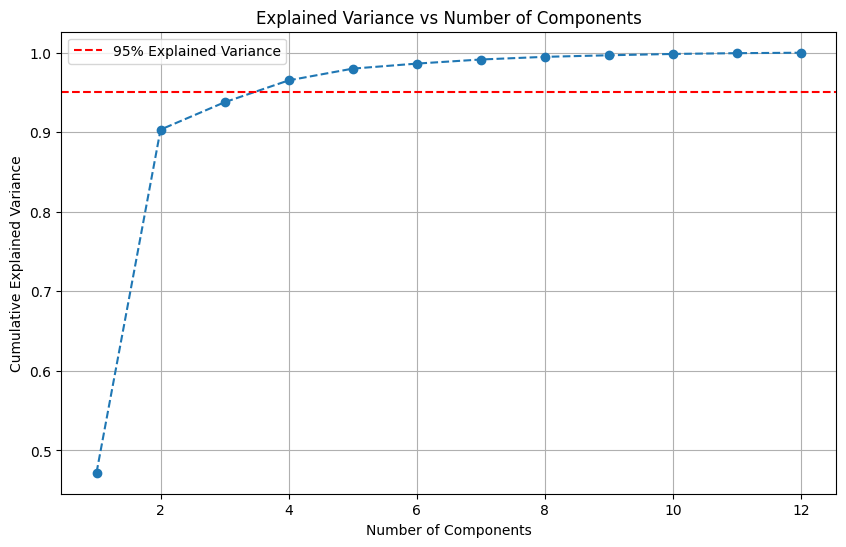

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Separate features (X) and labels (y)
X = df_merged.drop(columns=["label"])
y = df_merged["label"]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to determine explained variance
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Select the number of components that preserve ~95% variance
n_components = 12

print(f"Number of Components Selected: {n_components}")

# Apply PCA with the selected number of components
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# Split the data into 70% training and 30% validation
X_train, X_val, y_train, y_val = train_test_split(X_pca, y, test_size=0.3, random_state=42, stratify=y)

# Print shape of the new splits
print(f"Training Set Shape: {X_train.shape}, Labels: {y_train.shape}")
print(f"Validation Set Shape: {X_val.shape}, Labels: {y_val.shape}")

print(f"Training Set: {X_train}")

print(f"Validation Set: {y_train}")

cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='--', label="95% Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs Number of Components")
plt.legend()
plt.grid(True)
plt.show()

#RANDOM FOREST MODEL

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import jaccard_score
from sklearn.model_selection import GridSearchCV

In [ ]:
# Initialize the classifier
clf = RandomForestClassifier(n_estimators=300, random_state=42)

clf.fit(X_train, y_train)

In [ ]:
# Model Evaluation(Cross-Validation)
# Define Cross-Validation Strategy
k_folds = 10
cv = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Run Cross-Validation
cv_scores = cross_val_score(clf, X_val, y_val, cv=cv, scoring="jaccard_macro")

# Print results
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Jaccard Macro: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

In [ ]:
# Define hyperparameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
}

# Initialize Random Forest model
clf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Set up Grid Search
grid_search = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring="jaccard_macro",
    cv=3,
    verbose=2,
    n_jobs=-1
)

# Run Grid Search
print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

# Best hyperparameters
print(f"Best Hyperparameters: {grid_search.best_params_}")

Starting Grid Search...


NameError: name 'grid_search' is not defined

Predict Wageningen Landuse using PCA

In [ ]:
# Assuming 'scaler' is your StandardScaler object from training
X_wur_scaled = scaler.transform(X_wur)  # Standardize X_wur

# Assuming 'pca' is your PCA object from training
X_wur_pca = pca.transform(X_wur_scaled)  # Apply PCA to X_wur

# Now predict using the transformed data(PCA)
y_wur_pred = clf.predict(X_wur_pca)
print("Prediction completed!")

number_of_pixels = s2_wur.reshape(3,-1).shape[1]

# predictor always predicting zeros
y_pred_wur = y_wur_pred

submission_df = pd.DataFrame([y_pred_wur.reshape(-1)], index=["Predicted"]).T
submission_df.index.name = 'ID'
submission_df.to_csv("submission.csv")
print("writing submission to submission.csv")


submission_df.head()

Predict Wageningen Landuse without using PCA

In [ ]:
# Predict land cover classes for Wageningen
y_wur_pred = clf.predict(X_wur)
print("Prediction completed!")

number_of_pixels = s2_wur.reshape(3,-1).shape[1]

# predictor always predicting zeros
y_pred_wur = y_wur_pred

submission_df = pd.DataFrame([y_pred_wur.reshape(-1)], index=["Predicted"]).T
submission_df.index.name = 'ID'
submission_df.to_csv("submission.csv")
print("writing submission to submission.csv")


submission_df.head()

Prediction completed!
writing submission to submission.csv


,Predicted
ID,
0,4
1,4
2,4
3,4
4,1


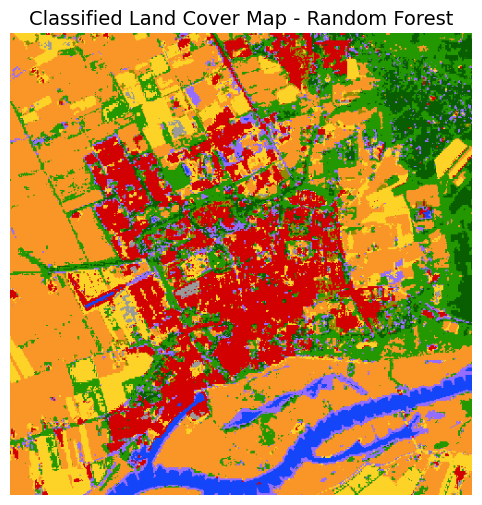

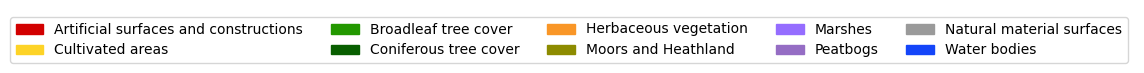

In [ ]:
# Reshape the prediction back to the original image size
classified_map = y_wur_pred.reshape(s2_wur.shape[1], s2_wur.shape[2])

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(classified_map, cmap=s2glc_cmap)  # Use the predefined land cover colormap

# Add title and remove axes
ax.set_title("Classified Land Cover Map - Random Forest", fontsize=14)
ax.axis("off")

# Add a color legend
plot_legend()

# Show the plot
plt.show()


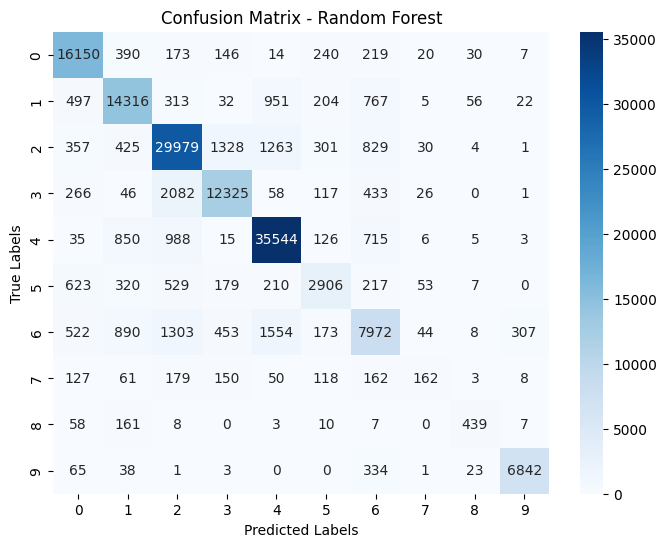

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute Confusion Matrix
y_val_pred = clf.predict(X_val)
cm = confusion_matrix(y_val, y_val_pred)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_val), yticklabels=np.unique(y_val))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - Random Forest")
plt.show()


# K-Nearest Neighbors

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, jaccard_score, f1_score


Uncomment the code block below if you have added the indices ndvi and ndwi in the training and validation data.

In [ ]:
# Ensure the column names are strings
#X_train.columns = X_train.columns.astype(str)
#X_val.columns = X_val.columns.astype(str)



Below there are 2 codeblocks which complete the model training. You should run the first one if you want to train the model without balanced classes. Otherwise you should run the second if you want to train the model with balanced classes

In [ ]:
pipeline = make_pipeline(
    StandardScaler(),  # Standardize the data
    KNeighborsClassifier()
)

param_grid = {
    'kneighborsclassifier__n_neighbors': [7, 11, 15, 20, 25],
    'kneighborsclassifier__metric': ['euclidean'],
    'kneighborsclassifier__weights': ['distance'],
}

grid_search = GridSearchCV(pipeline, param_grid, cv=7, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

print("Best hyperparameters found: ", grid_search.best_params_)


Fitting 7 folds for each of 5 candidates, totalling 35 fits
Best hyperparameters found:  {'kneighborsclassifier__metric': 'euclidean', 'kneighborsclassifier__n_neighbors': 7, 'kneighborsclassifier__weights': 'distance'}


Training the model with balanced classes

In [ ]:
pipeline = make_pipeline(
    StandardScaler(),  # Standardize the data
    KNeighborsClassifier()
)

param_grid = {
    'kneighborsclassifier__n_neighbors': [7, 11, 15, 20, 25],
    'kneighborsclassifier__metric': ['euclidean'],
    'kneighborsclassifier__weights': ['distance'],
}

grid_search = GridSearchCV(pipeline, param_grid, cv=7, n_jobs=-1, verbose=2)
grid_search.fit(X_train_bal, y_train)

print("Best hyperparameters found: ", grid_search.best_params_)


To evaluate the performance of the model, we check various metrics such as the Jaccard score and validation accuracy, which help assess how well the model with the best parameters predicts and generalizes to unseen data.

In [ ]:
# Get the best model after tuning
best_knn_model = grid_search.best_estimator_


# Make predictions on the validation set
y_val_pred = best_knn_model.predict(X_val)

# Compute validation accuracy
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.4f}")


Validation Accuracy: 0.8049


In [ ]:
# Calculate and print Jaccard score
jaccard = jaccard_score(y_val.to_numpy().flatten(), y_val_pred.flatten(), average='macro')
print(f"Jaccard Similarity: {jaccard:.4f}")



Jaccard Similarity: 0.5687


In [ ]:
# Get the best cross-validation score ( cross validation accuracy)
best_validation_accuracy = grid_search.best_score_
print(f"Best cross validation accuracy: {best_validation_accuracy:.4f}")

Best cross validation accuracy: 0.8013


Here we try to predict the test data (Wageningen image) with the best trained model.

In [ ]:
#Uncomment the below line if in the training and validation dataset include the NDVI and NDWI otherwise the prediction will be successfull.
#X_wur = df_wur.to_numpy()

In [ ]:
# Make predictions on X_wur (test data)
y_pred_wur = best_knn_model.predict(X_wur)

The code block below is used to plot the classified Wageningen Image.

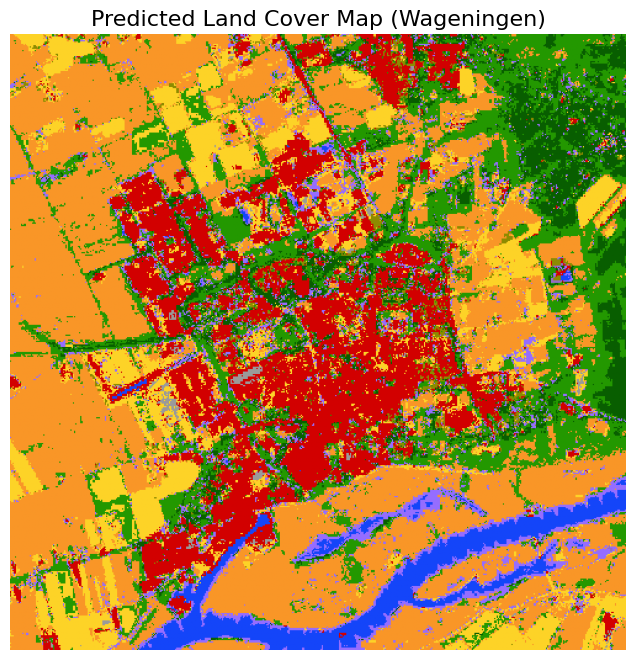

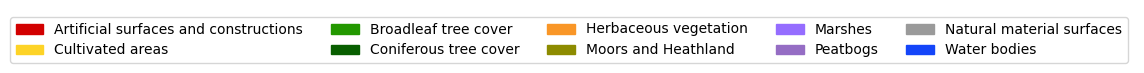

In [ ]:
# Function to plot the legend
def plot_legend():
    hex_colors = [v["color"] for v in color_map_entries.values()]
    color_names = [v["name"] for v in color_map_entries.values()]
    legend_elements = [Patch(color=color, label=name) for color, name in zip(hex_colors, color_names)]
    plt.figure(figsize=(.1, .1))
    plt.legend(handles=legend_elements, ncols=5, loc='upper right')
    plt.axis('off')

# Check if y_pred_wur matches the expected number of pixels
expected_pixels = s2_wur.shape[1] * s2_wur.shape[2]
assert y_pred_wur.shape[0] == expected_pixels, "Mismatch in prediction reshaping!"

# Reshape correctly
y_pred_wur_reshaped = y_pred_wur.reshape(s2_wur.shape[1], s2_wur.shape[2])


# Define the color map for land cover
hex_colors = [v["color"] for v in color_map_entries.values()]
s2glc_cmap = ListedColormap(hex_colors)

# Plot the predictions
plt.figure(figsize=(10, 8))
plt.imshow(y_pred_wur_reshaped, cmap=s2glc_cmap)  # This should now display with the correct colors
plt.title("Predicted Land Cover Map (Wageningen)", fontsize=16)
plt.axis("off")

# Add legend
plot_legend()

plt.show()

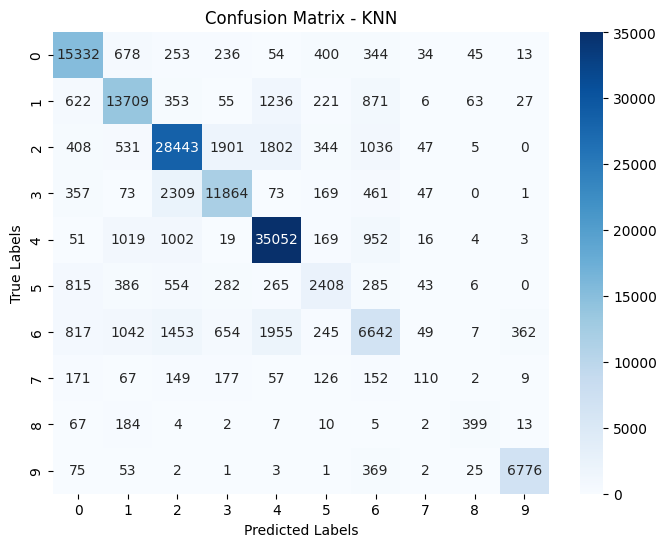

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


# Compute Confusion Matrix
cm_knn = confusion_matrix(y_val, y_val_pred)

# Get unique class labels
class_labels = np.unique(y_val)  # Extract unique labels from y_val

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - KNN")
plt.show()

In [ ]:

number_of_pixels = s2_wur.reshape(3,-1).shape[1]


submission_df = pd.DataFrame([y_pred_wur.reshape(-1)], index=["Predicted"]).T
submission_df.index.name = 'ID'
submission_df.to_csv("submission.csv")
print("writing submission to submission.csv")

writing submission to submission.csv


In [ ]:
print(submission_df)

        Predicted
ID               
0               4
1               4
2               4
3               1
4               1
...           ...
249995          4
249996          4
249997          4
249998          4
249999          4

[250000 rows x 1 columns]


AI Statement: In this report, artificial intelligence primarily assisted in writing Python code. It streamlined the implementation of classification models, data processing, and visualization while also offering valuable explanations to enhance understanding.